# P3 — Gradient Descent (GD)

Placement Prediction System — Gradient Descent implementation.

This notebook uses the CSV in the project's `data` folder, automatically cleans column names, detects a suitable numeric target, scales features, and implements Gradient Descent from scratch.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Load the placement dataset

In [2]:
DATA_DIR = r"C:\Users\tallu\Downloads\Placement-Prediction System\data"

csv_files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
if not csv_files:
    raise FileNotFoundError(f'No CSV files found in {DATA_DIR}')

preferred = [f for f in csv_files if 'placement' in os.path.basename(f).lower()]
CSV_PATH = preferred[0] if preferred else csv_files[0]

print("Using:", CSV_PATH)
df = pd.read_csv(CSV_PATH)
df.columns = [str(c).strip() for c in df.columns]
print('Shape:', df.shape)
display(df.head())
print('\nColumns:')
print(df.columns.tolist())


Using: C:\Users\tallu\Downloads\Placement-Prediction System\data\placement_predict_50k Dataset_final.csv
Shape: (50000, 32)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99



Columns:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']


## 2. Select the target column

GD requires a numeric target for this regression example. The notebook first looks for common salary/package names. If none is found, it selects the last numeric column.

In [3]:
def norm(s):
    return ''.join(ch.lower() for ch in str(s) if ch.isalnum())

target_names = [
    'Salary Package', 'Salary_Package', 'SalaryPackage',
    'Package', 'Salary', 'Salary_LPA', 'Package_LPA', 'CTC', 'LPA'
]

TARGET = None
lookup = {norm(c): c for c in df.columns}
for name in target_names:
    if norm(name) in lookup:
        TARGET = lookup[norm(name)]
        break

if TARGET is None:
    for c in df.columns:
        if any(x in norm(c) for x in ['salary', 'package', 'ctc', 'lpa']):
            test = pd.to_numeric(df[c], errors='coerce')
            if test.notna().sum() > 0:
                TARGET = c
                break

if TARGET is None:
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    if not numeric_cols:
        raise ValueError('No numeric target column could be detected. Set TARGET manually.')
    TARGET = numeric_cols[-1]

print('Target column:', TARGET)


Target column: Salary Package


## 3. Prepare numerical features

In [4]:
# Convert target to numeric
df[TARGET] = pd.to_numeric(
    df[TARGET].astype(str).str.replace(',', '', regex=False)
      .str.extract(r'([-+]?\d*\.?\d+)')[0],
    errors='coerce'
)
df = df.dropna(subset=[TARGET]).copy()

# Keep numeric predictors only for the from-scratch GD implementation.
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
feature_cols = [c for c in numeric_cols if c != TARGET]

# Remove obvious ID columns
feature_cols = [c for c in feature_cols if norm(c) not in {
    'id', 'studentid', 'studentno', 'studentnumber', 'rollno', 'rollnumber'
} and not norm(c).endswith('id')]

if not feature_cols:
    raise ValueError('No numeric predictor columns were found for GD.')

X = df[feature_cols].copy()
y = df[TARGET].to_numpy(dtype=float).reshape(-1, 1)

# Fill missing feature values with column medians
X = X.fillna(X.median(numeric_only=True))

print('Features:', feature_cols)
print('Target:', TARGET)
display(X.head())


Features: ['SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'PlacementStatus', 'IsAnomaly']
Target: Salary Package


,SGPA_Sem1,SGPA_Sem2,SGPA_Sem3,SGPA_Sem4,SGPA_Sem5,SGPA_Sem6,SGPA_Sem7,SGPA_Sem8,CGPA,AttendancePercent,...,Workshops,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,PlacementStatus,IsAnomaly
0,6.02,6.54,6.52,6.00,6.47,5.91,6.49,5.50,6.29,73.3,...,2.0,2,0,66.7,2.2,49.4,47.8,0,0,0
1,5.84,5.12,5.34,5.18,5.03,4.93,5.40,5.13,5.23,54.5,...,0.0,1,0,48.2,2.4,26.7,25.8,0,0,0
2,4.91,5.29,5.49,5.73,5.33,5.88,5.82,5.67,5.52,77.6,...,1.0,1,0,73.8,2.8,67.7,41.5,0,1,0
3,7.67,8.03,8.08,7.64,6.86,7.10,7.56,7.39,7.51,68.8,...,1.0,2,0,69.8,2.7,66.9,48.0,0,1,0
4,8.14,8.97,8.36,8.55,8.55,8.38,9.10,8.86,8.65,95.8,...,2.0,4,1,73.1,2.1,71.7,61.7,1,1,0


## 4. Standardize features

In [5]:
X_values = X.to_numpy(dtype=float)
X_mean = X_values.mean(axis=0)
X_std = X_values.std(axis=0)
X_std[X_std == 0] = 1

X_scaled = (X_values - X_mean) / X_std

# Add intercept column
X_gd = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

print('X shape after adding intercept:', X_gd.shape)


X shape after adding intercept: (50000, 23)


## 5. Gradient Descent from scratch

Model: `y_hat = Xθ`


Cost: `J(θ) = (1/(2m)) Σ(y_hat - y)²`


Update: `θ = θ - α (1/m) Xᵀ(Xθ - y)`

In [6]:
def gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    theta = np.zeros((n, 1))
    cost_history = []

    for epoch in range(epochs):
        y_pred = X @ theta
        error = y_pred - y
        cost = (1 / (2 * m)) * np.sum(error ** 2)
        cost_history.append(cost)

        gradient = (1 / m) * (X.T @ error)
        theta = theta - learning_rate * gradient

    return theta, cost_history

learning_rate = 0.01
epochs = 2000

theta, cost_history = gradient_descent(
    X_gd, y,
    learning_rate=learning_rate,
    epochs=epochs
)

print('Gradient Descent completed.')
print('Initial cost:', cost_history[0])
print('Final cost:', cost_history[-1])


Gradient Descent completed.
Initial cost: 84.404439628
Final cost: 6.536995992307589


## 6. Display learned parameters

In [7]:
parameter_names = ['Intercept'] + feature_cols
parameters = pd.DataFrame({'Parameter': parameter_names, 'Theta': theta.ravel()})
display(parameters)


,Parameter,Theta
0,Intercept,9.536119
1,SGPA_Sem1,0.678720
2,SGPA_Sem2,0.654862
3,SGPA_Sem3,0.607620
4,SGPA_Sem4,0.646152
5,SGPA_Sem5,0.650721
6,SGPA_Sem6,0.569478
7,SGPA_Sem7,0.528449
8,SGPA_Sem8,0.674993
9,CGPA,0.682035


## 7. Cost function convergence

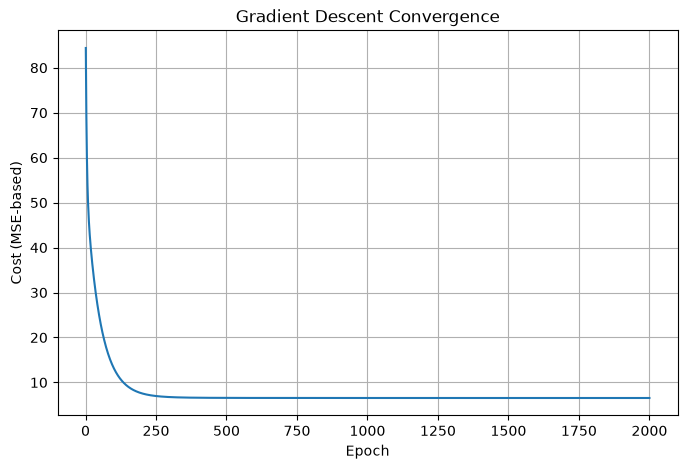

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), cost_history)
plt.xlabel('Epoch')
plt.ylabel('Cost (MSE-based)')
plt.title('Gradient Descent Convergence')
plt.grid(True)
plt.show()


## 8. Predictions and evaluation

In [9]:
y_pred = X_gd @ theta
error = y_pred - y

mae = np.mean(np.abs(error))
mse = np.mean(error ** 2)
rmse = np.sqrt(mse)
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan

print('Gradient Descent Results')
print('------------------------')
print(f'MAE  : {mae:.4f}')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')

results = pd.DataFrame({
    'Actual': y.ravel(),
    'Predicted': y_pred.ravel()
})
display(results.head(10))


Gradient Descent Results
------------------------
MAE  : 3.0748
MSE  : 13.0740
RMSE : 3.6158
R²   : 0.8321


,Actual,Predicted
0,0.00,1.060213
1,0.00,-2.221860
2,3.89,3.611409
3,8.37,11.221365
4,18.99,16.393051
5,18.17,21.331666
6,25.52,20.473166
7,0.00,-1.683536
8,5.51,8.422088
9,18.51,15.340011


## 9. Actual vs Predicted

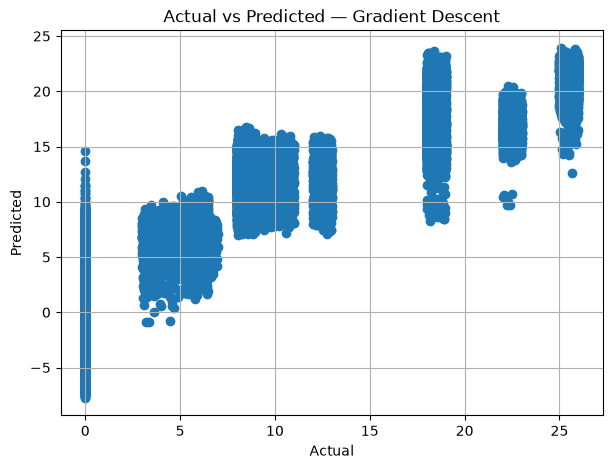

In [10]:
plt.figure(figsize=(7, 5))
plt.scatter(y, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted — Gradient Descent')
plt.grid(True)
plt.show()


## 10. Try different learning rates

In [11]:
learning_rates = [0.001, 0.01, 0.05]

for lr in learning_rates:
    _, history = gradient_descent(X_gd, y, learning_rate=lr, epochs=1000)
    print(f'Learning rate {lr}: final cost = {history[-1]:.4f}')


Learning rate 0.001: final cost = 13.1549
Learning rate 0.01: final cost = 6.5394
Learning rate 0.05: final cost = 6.5360
